# Notebook Analyse Statistique

Ce notebook reprend les **lights curves** en realisant un petit preprocessing des donnees, puis applique une **analyse statistique et probabiliste** : statistiques par composante, corrélations intra-lentille, comparaison à des paires aléatoires, et visualisations seaborn.

In [1]:

# Imports principaux
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import spearmanr, kurtosis, wasserstein_distance
from scipy.interpolate import interp1d

# Style graphique
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)


## 0.b Export automatique des figures

Cette section prépare l'export des figures vers un dossier dédié pour une future présentation.
Les fichiers seront enregistrés avec des noms propres et réutilisables dans Beamer ou PowerPoint.


In [2]:
FIGURES_DIR = Path("figures_presentation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(name, fig=None, dpi=300, bbox_inches="tight", transparent=False):
    """Sauvegarde une figure matplotlib dans le dossier de présentation.

    Parameters
    ----------
    name : str
        Nom du fichier, avec ou sans extension.
    fig : matplotlib.figure.Figure or None
        Figure à sauvegarder. Si None, utilise la figure courante.
    dpi : int
        Résolution de l'image exportée.
    bbox_inches : str
        Paramètre matplotlib pour rogner les marges.
    transparent : bool
        Fond transparent ou non.
    """
    if fig is None:
        fig = plt.gcf()
    name = str(name)
    if not name.lower().endswith((".png", ".pdf", ".jpg", ".jpeg", ".svg")):
        name = f"{name}.png"
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches=bbox_inches, transparent=transparent)
    print(f"Figure exportée : {path.resolve()}")
    return path

print(f"Dossier d'export des figures : {FIGURES_DIR.resolve()}")


Dossier d'export des figures : C:\Users\tpichard\PyCS\figures_presentation


## 1. Chargement et nettoyage des données

In [3]:

# ------------------------------------------------------------------
# 1) Chargement des données brutes
# ------------------------------------------------------------------
# Adapte ce chemin si ton CSV n'est pas dans ce dossier.
path = Path("data/dgdreq2025nov21_JB.csv")
df = pd.read_csv(path)

# Conversion explicite des colonnes utiles
for c in ["source_id", "lensComponentSourceId", "epoch_obs_jd", "flux_obs", "flux_obs_error"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Nettoyage minimal
# On retire les lignes inexploitables pour l'analyse temporelle / photométrique.
df = df.dropna(subset=["source_id", "lensComponentSourceId", "epoch_obs_jd", "flux_obs", "flux_obs_error"]).copy()
df = df[(df["flux_obs"] > 0) & (df["flux_obs_error"] > 0)].copy()

df["source_id"] = df["source_id"].astype("int64")
df["lensComponentSourceId"] = df["lensComponentSourceId"].astype("int64")
df = df.sort_values(["source_id", "lensComponentSourceId", "epoch_obs_jd"]).reset_index(drop=True)

print(df.shape)
df.head()


(45858, 6)


,source_id,lensComponentSourceId,flux_obs,flux_obs_error,isFluxCalibrated,epoch_obs_jd
0,63971411866955904,63971411866955969,546.930227,12.096125,0,2.456907e+06
1,63971411866955904,63971411866955969,546.816246,9.297076,0,2.457028e+06
2,63971411866955904,63971411866955969,548.703230,7.708399,0,2.457038e+06
3,63971411866955904,63971411866955969,547.692598,6.074010,0,2.457038e+06
4,63971411866955904,63971411866955969,530.256199,5.971939,0,2.457214e+06


## 2. Organisation des données par source et composante

In [4]:

# ------------------------------------------------------------------
# 2) Dictionnaire par source puis par composante
# ------------------------------------------------------------------
# Structure pratique pour explorer rapidement une source et ses composantes.
data_by_source = {
    int(source_id): {
        int(comp_id): g_comp[["epoch_obs_jd", "flux_obs", "flux_obs_error", "isFluxCalibrated"]].reset_index(drop=True)
        for comp_id, g_comp in g_source.groupby("lensComponentSourceId", sort=False)
    }
    for source_id, g_source in df.groupby("source_id", sort=False)
}

print(f"Nombre de sources: {len(data_by_source)}")
first_key = next(iter(data_by_source))
print("Exemple source_id:", first_key)
print("Composantes:", list(data_by_source[first_key].keys())[:10])


Nombre de sources: 388
Exemple source_id: 63971411866955904
Composantes: [63971411866955969, 63971411866955971]


## 3. Flags de lentilles

On garde deux notions : les **lentilles connues** issues de la liste du PlayBook, et les **sources multi-composantes** (utile pour une analyse exploratoire plus large).

In [11]:
#Id des Lentilles connues lentille_ids = []
lentille_ids = [5077935264216200832,
 2216740927658907648,
 1910735807875873664,
 2623596445097415040,
 395754921063313024,
 380075812236197760,
 2348420123825646336,
 2373803788569100160,
 4999447421238071936,
 2369490546185699328,
 2355800355108946432,
 2371361983695995264,
 2804295954148390272,
 2358531232755701504,
 2531819311878644096,
 4915503625466318464,
 372057559265314688,
 2533897461870477568,
 322056271561143680,
 291933776127888768,
 2561983348235519360,
 318810027903595392,
 2457482365811994368,
 2464353660650971520,
 2460545948804796032,
 350937280929196928,
 4954121596274054400,
 4960819894125714944,
 5026013408869280128,
 4955044292688756224,
 5024429528010102144,
 4956574748452174592,
 5148785186464567168,
 4956634220861679360,
 76904623545392512,
 4971233295737205760,
 4964421000864875904,
 5124658637175794048,
 4643616493228910080,
 337933769222851840,
 2515417110948750976,
 5119328548401927936,
 5119104866505106688,
 5184007624848431872,
 5174409201871203584,
 549281756875772672,
 5075630859644356480,
 5174520836660663296,
 83871575896093312,
 114294031844958720,
 5153686358329651840,
 5153828508862119040,
 5098921578230761472,
 3261414236903292160,
 4674636224510336256,
 5085135764002995584,
 63971411866955904,
 4672765852152430848,
 5087747928752251776,
 4834883855209175296,
 4683151559814721920,
 5082980996090316800,
 4842045799074927232,
 4845606606136183424,
 4883180423150691584,
 4830236636170244480,
 4779902849277205760,
 4778637895508914048,
 175720825910626304,
 3178020716638059264,
 3185808420059318016,
 4894145268500809728,
 4877987734675447936,
 4624301922220808832,
 3187010529866092672,
 4813484648808076544,
 4770993403477832064,
 2959785663027256832,
 2959142032112859264,
 4826116113268202112,
 4807486087029366784,
 196343055547397888,
 2903556569666059648,
 2966721824756464896,
 2903331715240526592,
 5571267199383508096,
 2916884609097868672,
 960989934527118848,
 1116767058322038656,
 5261791097486778624,
 3000185396729743104,
 1103603357219723904,
 3385786701564912384,
 2933340793481678208,
 3361094865862486656,
 986525370526178176,
 5585883698943303296,
 871794729486078336,
 672293537240480768,
 3138952727746236800,
 867913659598182272,
 3164374261215669888,
 925907232901783296,
 921013100488801920,
 670520540382618496,
 5694395291770945280,
 3097346657995436800,
 649514817411198976,
 679072919780579200,
 1097468636388676608,
 3092314541167221760,
 3080259323881652608,
 5643847512428416384,
 5641500188236488704,
 1016218227493362816,
 607381016436338560,
 712654684950723072,
 3842934499335828608,
 1043171896055716608,
 580537092879961472,
 1022663637669586176,
 698878899471973120,
 695593902327484544,
 817452844753700736,
 3844748070752040576,
 817592276569391488,
 5691734916002651136,
 1026420252290292480,
 3851608129957910400,
 641511742854886144,
 613773504026183808,
 621369175165121408,
 797882950824323584,
 807714470266431488,
 646884373280519936,
 5672017928032611840,
 5687124801186026880,
 3832692033126977664,
 1045166002126206720,
 827031141513223936,
 806853178999388928,
 3834882054131088512,
 3876832198007366912,
 5666444778469974656,
 730552393494441856,
 3552950883176150016,
 3817878828362669568,
 3541826024524572544,
 1537658249711963904,
 6159550763996866944,
 3941492797505654784,
 3511426761399556352,
 3733119018870073216,
 1475457506834977280,
 1469230594530741760,
 3711531005707407104,
 3728132222538228864,
 1454504418686043904,
 1599341745383363328]


# On crée un flag de lentille "connue" à partir de la liste du PlayBook.
lentille_set = set(int(x) for x in lentille_ids)
df["is_lens_known"] = df["source_id"].isin(lentille_set).astype("int8")

# Et un flag plus large, purement structurel : source avec au moins 2 composantes.
ncomp = df.groupby("source_id")["lensComponentSourceId"].nunique()
structural_lens_sources = set(ncomp[ncomp >= 2].index)
df["is_lens_structural"] = df["source_id"].isin(structural_lens_sources).astype("int8")

print("Nombre de mesures:", len(df["source_id"]))
print("Sources inclues dans une lentille >= 2:", len(structural_lens_sources))


Nombre de mesures: 45858
Sources inclues dans une lentille >= 2: 340


## 4. Passage en magnitude relative et alignement des composantes

On enrichit `df` avec `mag_obs`, `mag_obs_error`, `baseline_shift` et `mag_aligned`.

In [12]:
def add_relative_magnitude(df, flux_col="flux_obs", err_col="flux_obs_error", ct_obs=25.6233):
    '''Take an obs flux and spit out the same data but in mag relative
    '''
    df = df.copy()
    msk = df[flux_col].notna() & (df[flux_col] > 0) & df[err_col].notna() & (df[err_col] > 0)
    df = df[msk].copy()

    df["mag_obs"] = -2.5 * np.log10(df[flux_col].astype(float)) + ct_obs
    df["mag_obs_error"] = (2.5 / np.log(10)) * (df[err_col].astype(float) / df[flux_col].astype(float))
    return df

def wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    return np.sum(w * x) / np.sum(w)

def align_components_on_common_mean(
    df,
    source_col="source_id",
    comp_col="lensComponentSourceId",
    value_col="mag_obs",
    err_col="mag_obs_error",
    out_shift_col="baseline_shift",
    out_value_col="mag_aligned",
):
    """
    Ajoute deux colonnes:
      - out_shift_col : décalage appliqué à chaque composante d'une même source
      - out_value_col : valeur alignée (value_col + shift)
    Sans modifier les lignes, l'index, ni l'ordre du DataFrame d'entrée.
    """
    out = df.copy()

    # poids
    w = 1.0 / (out[err_col].astype(float) ** 2)
    out["_w_tmp"] = w

    # moyenne pondérée par (source, composante)
    # mu_sc = sum(w*y)/sum(w)
    grp_sc = out.groupby([source_col, comp_col], sort=False)
    sum_wy = grp_sc.apply(lambda g: np.sum(g["_w_tmp"] * g[value_col].astype(float)))
    sum_w  = grp_sc["_w_tmp"].sum()
    mu_sc = (sum_wy / sum_w).rename("mu_sc")  # MultiIndex (source, comp)

    # moyenne de référence par source = moyenne des moyennes de composantes
    mu_ref = mu_sc.groupby(level=0).mean().rename("mu_ref")  # index=source

    # shift par (source, comp) : mu_ref(source) - mu_sc(source, comp)
    shift_sc = (mu_ref.reindex(mu_sc.index.get_level_values(0)).to_numpy() - mu_sc.to_numpy())
    shift_sc = pd.Series(shift_sc, index=mu_sc.index, name=out_shift_col)

    # mapper le shift sur chaque ligne (source, comp)
    keys = list(zip(out[source_col].astype("Int64"), out[comp_col].astype("Int64")))
    out[out_shift_col] = pd.Index(keys).map(shift_sc)

    # valeur alignée
    out[out_value_col] = out[value_col].astype(float) + out[out_shift_col].astype(float)

    # nettoyage
    out.drop(columns=["_w_tmp"], inplace=True)

    return out


# ------------------------------------------------------------------
# 3) Passage flux -> magnitude relative puis alignement par source
# ------------------------------------------------------------------
# On garde df comme table principale enrichie.
df = add_relative_magnitude(df)
df = align_components_on_common_mean(df)

df[[
    "source_id", "lensComponentSourceId", "epoch_obs_jd",
    "flux_obs", "flux_obs_error", "mag_obs", "mag_obs_error",
    "baseline_shift", "mag_aligned"
]].head()


,source_id,lensComponentSourceId,epoch_obs_jd,flux_obs,flux_obs_error,mag_obs,mag_obs_error,baseline_shift,mag_aligned
0,63971411866955904,63971411866955969,2.456907e+06,546.930227,12.096125,18.778470,0.024013,0.135106,18.913576
1,63971411866955904,63971411866955969,2.457028e+06,546.816246,9.297076,18.778696,0.018460,0.135106,18.913802
2,63971411866955904,63971411866955969,2.457038e+06,548.703230,7.708399,18.774956,0.015253,0.135106,18.910062
3,63971411866955904,63971411866955969,2.457038e+06,547.692598,6.074010,18.776958,0.012041,0.135106,18.912063
4,63971411866955904,63971411866955969,2.457214e+06,530.256199,5.971939,18.812086,0.012228,0.135106,18.947191


## 5. Visualisation rapide d'une lentille connue

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\lens_known_example_source_4971233295737205760.png


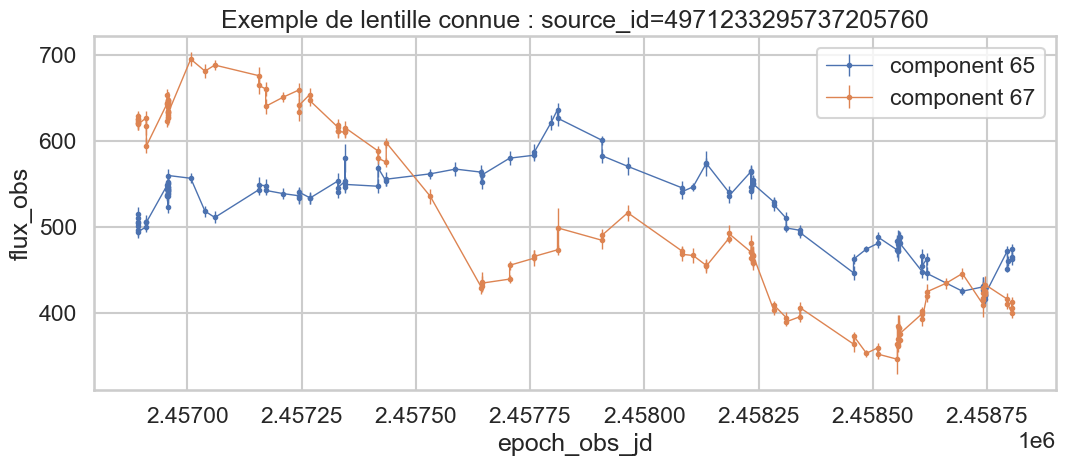

In [13]:

# ------------------------------------------------------------------
# 4) Visualisation rapide d'une lentille connue
# ------------------------------------------------------------------
df_lens_known = df[df["is_lens_known"] == 1].copy()
stats_known = (
    df_lens_known.groupby("source_id")
    .agg(n_comp=("lensComponentSourceId", "nunique"), n_obs=("epoch_obs_jd", "size"))
    .sort_values(["n_obs", "n_comp"], ascending=False)
)

if not stats_known.empty:
    example_source_id = int(stats_known.index[6])
    sub = df_lens_known[df_lens_known["source_id"] == example_source_id].copy()
    sub = sub.sort_values(["lensComponentSourceId", "epoch_obs_jd"])

    plt.figure(figsize=(11, 5))
    for comp_id, g in sub.groupby("lensComponentSourceId"):
        plt.errorbar(
            g["epoch_obs_jd"], g["flux_obs"], yerr=g["flux_obs_error"],
            fmt="o-", markersize=3, linewidth=1, label=f"component {int(comp_id - example_source_id)}"
        )
    plt.xlabel("epoch_obs_jd")
    plt.ylabel("flux_obs")
    plt.title(f"Exemple de lentille connue : source_id={example_source_id}")
    plt.legend()
    plt.tight_layout()
    save_figure(f"lens_known_example_source_{example_source_id}", fig=plt.gcf())
    plt.show()
else:
    print("Aucune lentille connue trouvée dans les données chargées.")


## 6. Préparation de la table de travail pour l'analyse statistique

In [14]:

# ------------------------------------------------------------------
# 5) Préparation de la table de travail pour l'analyse statistique
# ------------------------------------------------------------------
# On repart de df enrichi par le préprocessing du PlayBook.
work = df.copy()

# Choix du flag pour les comparaisons :
# - is_lens_known : lentilles de la liste du PlayBook
# - is_lens_structural : toute source ayant >=2 composantes
# Ici on garde les deux, mais l'analyse globale s'appuie sur le critère structurel.
work["is_lens"] = work["is_lens_structural"].astype("int8")

# Variables utiles pour les statistiques.
work["snr"] = work["flux_obs"] / work["flux_obs_error"]
work["ivar"] = 1.0 / (work["flux_obs_error"] ** 2)

# Standardisation robuste par composante pour comparer des courbes de niveaux différents.
def robust_standardize(g):
    sid, cid = g.name
    g = g.sort_values("epoch_obs_jd").copy()

    med = np.median(g["flux_obs"])
    mad = np.median(np.abs(g["flux_obs"] - med))
    scale = 1.4826 * mad if mad > 0 else np.std(g["flux_obs"])

    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0

    g["flux_z"] = (g["flux_obs"] - med) / scale
    g["flux_err_z"] = g["flux_obs_error"] / scale
    g["time_rel"] = g["epoch_obs_jd"] - g["epoch_obs_jd"].min()

    g["source_id"] = sid
    g["lensComponentSourceId"] = cid

    return g

work = (
    work.groupby(["source_id", "lensComponentSourceId"], group_keys=False)
        .apply(robust_standardize)
        .reset_index(drop=True)
)
work.head()


,flux_obs,flux_obs_error,isFluxCalibrated,epoch_obs_jd,is_lens_known,is_lens_structural,mag_obs,mag_obs_error,baseline_shift,mag_aligned,is_lens,snr,ivar,flux_z,flux_err_z,time_rel,source_id,lensComponentSourceId
0,546.930227,12.096125,0,2.456907e+06,1,1,18.778470,0.024013,0.135106,18.913576,1,45.215327,0.006835,0.429305,0.168640,0.000000,63971411866955904,63971411866955969
1,546.816246,9.297076,0,2.457028e+06,1,1,18.778696,0.018460,0.135106,18.913802,1,58.815941,0.011569,0.427716,0.129616,121.444512,63971411866955904,63971411866955969
2,548.703230,7.708399,0,2.457038e+06,1,1,18.774956,0.015253,0.135106,18.910062,1,71.182514,0.016830,0.454024,0.107468,130.698452,63971411866955904,63971411866955969
3,547.692598,6.074010,0,2.457038e+06,1,1,18.776958,0.012041,0.135106,18.912063,1,90.169851,0.027105,0.439934,0.084682,130.772435,63971411866955904,63971411866955969
4,530.256199,5.971939,0,2.457214e+06,1,1,18.812086,0.012228,0.135106,18.947191,1,88.791289,0.028039,0.196842,0.083258,306.778502,63971411866955904,63971411866955969


## 7. Fonctions statistiques

On définit ici les statistiques robustes, pondérées et les métriques de variabilité intrinsèque utilisées ensuite.

In [15]:
def safe_mean(x):
    """Myenne ou on enleve les valeurs qui ne vont pas
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return np.nan if len(x) == 0 else np.mean(x)

def safe_var(x):
    """Variance ou on enleve les valeurs qui ne vont pas
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return np.nan if len(x) < 2 else np.var(x, ddof=1)

def weighted_mean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return np.sum(x[m] * w[m]) / np.sum(w[m])

def normalized_excess_variance(flux, flux_err):
    flux = np.asarray(flux, float)
    flux_err = np.asarray(flux_err, float)
    m = np.isfinite(flux) & np.isfinite(flux_err) & (flux_err > 0)
    flux = flux[m]
    flux_err = flux_err[m]
    n = len(flux)
    if n < 2:
        return np.nan, np.nan, np.nan
    
    mu = np.mean(flux)
    s2 = np.var(flux, ddof=1)
    mean_err2 = np.mean(flux_err**2)
    xs_var = s2 - mean_err2
    
    if mu <= 0:
        return np.nan, xs_var, np.nan
    
    nxs = xs_var / (mu**2)
    err_nxs = np.sqrt(
        (np.sqrt(2.0 / n) * mean_err2 / (mu**2))**2 +
        (np.sqrt(mean_err2 / n) * 2.0 * np.sqrt(max(xs_var, 0)) / (mu**2))**2
    )
    return nxs, xs_var, err_nxs

def weighted_kurtosis(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[m], w[m]
    if len(x) < 4:
        return np.nan
    mu = np.sum(w * x) / np.sum(w)
    v = np.sum(w * (x - mu)**2) / np.sum(w)
    if v <= 0:
        return np.nan
    m4 = np.sum(w * (x - mu)**4) / np.sum(w)
    return m4 / (v**2) - 3.0

def structure_function_slope(time, flux, flux_err, n_bins=12):
    """
    Stat utile pour 'flow matching' plus tard :
    pente approx de la structure function, incluant les erreurs.
    -> But d'etre capable d'apprendre a reproduire un comportement
    """
    t = np.asarray(time, float)
    f = np.asarray(flux, float)
    e = np.asarray(flux_err, float)
    m = np.isfinite(t) & np.isfinite(f) & np.isfinite(e)
    t, f, e = t[m], f[m], e[m]
    if len(t) < 10:
        return np.nan
    
    dt_list, sf_list = [], []
    for i in range(len(t)):
        for j in range(i + 1, len(t)):
            dt = abs(t[j] - t[i])
            val = (f[j] - f[i])**2 - (e[j]**2 + e[i]**2)
            if dt > 0 and np.isfinite(val):
                dt_list.append(dt)
                sf_list.append(max(val, 1e-12))
    
    if len(dt_list) < 10:
        return np.nan
    
    dt = np.array(dt_list)
    sf = np.array(sf_list)
    
    bins = np.quantile(dt, np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)
    if len(bins) < 4:
        return np.nan
    
    xmid, ymed = [], []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        mm = (dt >= b0) & (dt < b1)
        if mm.sum() >= 5:
            xmid.append(np.median(dt[mm]))
            ymed.append(np.median(sf[mm]))
    
    if len(xmid) < 3:
        return np.nan
    
    xmid = np.log10(np.array(xmid))
    ymed = np.log10(np.array(ymed))
    slope = np.polyfit(xmid, ymed, 1)[0]
    return slope

component_stats = []
for (sid, cid), g in work.groupby(["source_id", "lensComponentSourceId"]):
    nxs, xs_var, err_nxs = normalized_excess_variance(g["flux_obs"], g["flux_obs_error"])
    component_stats.append({
        "source_id": sid,
        "lensComponentSourceId": cid,
        "n_obs": len(g),
        "t_span_days": g["epoch_obs_jd"].max() - g["epoch_obs_jd"].min(),
        "flux_mean": safe_mean(g["flux_obs"]),
        "flux_std": np.std(g["flux_obs"], ddof=1) if len(g) > 1 else np.nan,
        "err_mean": safe_mean(g["flux_obs_error"]),
        "snr_median": np.median(g["snr"]),
        "kurtosis_fisher": kurtosis(g["flux_obs"], fisher=True, bias=False) if len(g) >= 4 else np.nan,
        "weighted_kurtosis": weighted_kurtosis(g["flux_obs"], g["ivar"]),
        "nxs": nxs,
        "xs_var": xs_var,
        "nxs_err": err_nxs,
        "sf_slope": structure_function_slope(g["epoch_obs_jd"], g["flux_obs"], g["flux_obs_error"]),
        "is_lens": int(g["is_lens"].iloc[0]),
    })

stats_comp = pd.DataFrame(component_stats)
stats_comp.head()

,source_id,lensComponentSourceId,n_obs,t_span_days,flux_mean,flux_std,err_mean,snr_median,kurtosis_fisher,weighted_kurtosis,nxs,xs_var,nxs_err,sf_slope,is_lens
0,63971411866955904,63971411866955969,37,1854.007231,501.219070,117.955744,8.328539,65.702807,0.555386,-0.162789,0.055061,13832.513224,0.001388,1.061182,1
1,63971411866955904,63971411866955971,21,1838.917174,380.518409,80.116159,6.228177,65.310329,-1.435435,-1.632217,0.044036,6376.119121,0.001571,1.846129,1
2,76904623545392512,76904623545392577,48,1962.246961,366.973688,9.704821,7.160181,53.927339,2.075171,1.746145,0.000288,38.742995,0.000130,-2.879617,1
3,76904623545392512,76904623545392579,10,1197.907636,59.954852,12.895757,4.974854,12.279778,0.313182,-0.375631,0.039076,140.462704,0.011076,NaN,1
4,76904623545392512,76904623545392581,3,902.959679,67.373712,11.725038,5.504882,12.657444,NaN,NaN,0.023102,104.865788,0.015991,NaN,1


## 8. Fonctions de comparaison entre composantes

Interpolation sur grille commune, corrélation pondérée et similarité de distributions.

In [16]:
def interpolate_on_common_grid(g1, g2, time_col="epoch_obs_jd", value_col="flux_z", err_col="flux_err_z", n_grid=150):
    g1 = g1.sort_values(time_col)
    g2 = g2.sort_values(time_col)
    
    tmin = max(g1[time_col].min(), g2[time_col].min())
    tmax = min(g1[time_col].max(), g2[time_col].max())
    if not np.isfinite(tmin) or not np.isfinite(tmax) or tmax <= tmin:
        return None
    
    grid = np.linspace(tmin, tmax, n_grid)
    
    f1 = interp1d(g1[time_col], g1[value_col], bounds_error=False, fill_value=np.nan)
    f2 = interp1d(g2[time_col], g2[value_col], bounds_error=False, fill_value=np.nan)
    e1 = interp1d(g1[time_col], g1[err_col], bounds_error=False, fill_value=np.nan)
    e2 = interp1d(g2[time_col], g2[err_col], bounds_error=False, fill_value=np.nan)
    
    y1, y2 = f1(grid), f2(grid)
    s1, s2 = e1(grid), e2(grid)
    
    m = np.isfinite(y1) & np.isfinite(y2) & np.isfinite(s1) & np.isfinite(s2) & (s1 > 0) & (s2 > 0)
    if m.sum() < 10:
        return None
    
    return grid[m], y1[m], y2[m], s1[m], s2[m]

def weighted_corr(x, y, w):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    w = np.asarray(w, float)
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[m], y[m], w[m]
    if len(x) < 3:
        return np.nan
    mx = np.sum(w * x) / np.sum(w)
    my = np.sum(w * y) / np.sum(w)
    cov = np.sum(w * (x - mx) * (y - my)) / np.sum(w)
    vx = np.sum(w * (x - mx)**2) / np.sum(w)
    vy = np.sum(w * (y - my)**2) / np.sum(w)
    if vx <= 0 or vy <= 0:
        return np.nan
    return cov / np.sqrt(vx * vy)

def flow_similarity_hist(x, y, bins=50, r=(-4, 4)):
    hx, _ = np.histogram(x, bins=bins, range=r, density=True)
    hy, _ = np.histogram(y, bins=bins, range=r, density=True)
    if np.std(hx) == 0 or np.std(hy) == 0:
        return np.nan
    return np.corrcoef(hx, hy)[0, 1]

pair_rows = []

for sid, gs in work[work["is_lens"] == 1].groupby("source_id"):
    comps = list(gs["lensComponentSourceId"].unique())
    comps = sorted(comps)
    for i in range(len(comps)):
        for j in range(i + 1, len(comps)):
            c1, c2 = comps[i], comps[j]
            g1 = gs[gs["lensComponentSourceId"] == c1].copy()
            g2 = gs[gs["lensComponentSourceId"] == c2].copy()
            
            interp = interpolate_on_common_grid(g1, g2)
            if interp is None:
                continue
            
            grid, y1, y2, s1, s2 = interp
            w = 1.0 / (s1**2 + s2**2)
            
            pear = np.corrcoef(y1, y2)[0, 1] if len(y1) > 2 else np.nan
            spear = spearmanr(y1, y2).correlation if len(y1) > 2 else np.nan
            wcorr = weighted_corr(y1, y2, w)
            wdist = wasserstein_distance(g1["flux_z"], g2["flux_z"])
            fsim = flow_similarity_hist(g1["flux_z"], g2["flux_z"])
            
            pair_rows.append({
                "source_id": sid,
                "comp_1": c1,
                "comp_2": c2,
                "n_common": len(grid),
                "pearson_interp": pear,
                "spearman_interp": spear,
                "weighted_corr_interp": wcorr,
                "wasserstein_flux_z": wdist,
                "flow_corr_hist": fsim,
                "ncomp_source": len(comps),
            })

pairs_same_lens = pd.DataFrame(pair_rows)
pairs_same_lens.head()

,source_id,comp_1,comp_2,n_common,pearson_interp,spearman_interp,weighted_corr_interp,wasserstein_flux_z,flow_corr_hist,ncomp_source
0,63971411866955904,63971411866955969,63971411866955971,150,0.763156,0.805879,0.775417,1.308174,0.576125,2
1,76904623545392512,76904623545392577,76904623545392579,150,-0.379812,-0.387671,-0.406035,0.658268,0.316731,5
2,76904623545392512,76904623545392577,76904623545392581,150,-0.109619,-0.048868,-0.059974,0.403396,0.388672,5
3,76904623545392512,76904623545392577,76904623545392583,150,-0.006600,-0.008831,-0.038548,14.378982,0.390993,5
4,76904623545392512,76904623545392577,76904623545392585,150,-0.244151,-0.203044,-0.073631,1.240569,0.390993,5


## 9. Calcul des statistiques par composante

In [27]:

# ------------------------------------------------------------------
# 6) Statistiques par composante
# ------------------------------------------------------------------
component_stats = []
for (sid, cid), g in work.groupby(["source_id", "lensComponentSourceId"]):
    nxs, xs_var, err_nxs = normalized_excess_variance(g["flux_obs"], g["flux_obs_error"])
    component_stats.append({
        "source_id": sid,
        "lensComponentSourceId": cid,
        "n_obs": len(g),
        "t_span_days": g["epoch_obs_jd"].max() - g["epoch_obs_jd"].min(),
        "flux_mean": safe_mean(g["flux_obs"]),
        "flux_std": np.std(g["flux_obs"], ddof=1) if len(g) > 1 else np.nan,
        "err_mean": safe_mean(g["flux_obs_error"]),
        "snr_median": np.median(g["snr"]),
        "snr_mean": np.mean(g["snr"]),
        "kurtosis_fisher": kurtosis(g["flux_obs"], fisher=True, bias=False) if len(g) >= 4 else np.nan,
        "weighted_kurtosis": weighted_kurtosis(g["flux_obs"], g["ivar"]),
        "nxs": nxs,
        "xs_var": xs_var,
        "nxs_err": err_nxs,
        "sf_slope": structure_function_slope(g["epoch_obs_jd"], g["flux_obs"], g["flux_obs_error"]),
        "is_lens": int(g["is_lens"].iloc[0]),
        "is_lens_known": int(g["is_lens_known"].iloc[0]),
    })

stats_comp = pd.DataFrame(component_stats)
print(stats_comp.shape)
stats_comp.head()


(913, 17)


,source_id,lensComponentSourceId,n_obs,t_span_days,flux_mean,flux_std,err_mean,snr_median,snr_mean,kurtosis_fisher,weighted_kurtosis,nxs,xs_var,nxs_err,sf_slope,is_lens,is_lens_known
0,63971411866955904,63971411866955969,37,1854.007231,501.219070,117.955744,8.328539,65.702807,65.078142,0.555386,-0.162789,0.055061,13832.513224,0.001388,1.061182,1,1
1,63971411866955904,63971411866955971,21,1838.917174,380.518409,80.116159,6.228177,65.310329,64.847698,-1.435435,-1.632217,0.044036,6376.119121,0.001571,1.846129,1,1
2,76904623545392512,76904623545392577,48,1962.246961,366.973688,9.704821,7.160181,53.927339,54.749338,2.075171,1.746145,0.000288,38.742995,0.000130,-2.879617,1,1
3,76904623545392512,76904623545392579,10,1197.907636,59.954852,12.895757,4.974854,12.279778,12.495165,0.313182,-0.375631,0.039076,140.462704,0.011076,NaN,1,1
4,76904623545392512,76904623545392581,3,902.959679,67.373712,11.725038,5.504882,12.657444,13.746844,NaN,NaN,0.023102,104.865788,0.015991,NaN,1,1


## 10. Construction des paires intra-lentille et des paires aléatoires

In [18]:
# Stat composante -> merge pour construire des paires globales
comp_meta = stats_comp[[
    "source_id", "lensComponentSourceId", "n_obs", "t_span_days",
    "flux_mean", "flux_std", "snr_median", "nxs", "nxs_err", "sf_slope", "is_lens"
]].copy()

# Paires aléatoires globales de composantes
rng = np.random.default_rng(42)
all_components = comp_meta[["source_id", "lensComponentSourceId"]].drop_duplicates().values.tolist()

random_rows = []
n_random = min(2000, max(300, len(all_components) * 3))

for _ in range(n_random):
    (sid1, cid1), (sid2, cid2) = rng.choice(all_components, size=2, replace=False)
    g1 = work[(work["source_id"] == sid1) & (work["lensComponentSourceId"] == cid1)]
    g2 = work[(work["source_id"] == sid2) & (work["lensComponentSourceId"] == cid2)]
    
    if len(g1) < 10 or len(g2) < 10:
        continue
    
    fsim = flow_similarity_hist(g1["flux_z"], g2["flux_z"])
    wdist = wasserstein_distance(g1["flux_z"], g2["flux_z"])
    
    random_rows.append({
        "same_source": int(sid1 == sid2),
        "source_id_1": sid1,
        "comp_1": cid1,
        "source_id_2": sid2,
        "comp_2": cid2,
        "flow_corr_hist": fsim,
        "wasserstein_flux_z": wdist,
    })

pairs_random = pd.DataFrame(random_rows)

global_compare = pd.concat([
    pairs_same_lens.assign(group="same_lens")[["flow_corr_hist", "wasserstein_flux_z", "group"]],
    pairs_random.assign(group=np.where(pairs_random["same_source"] == 1, "same_lens_random_hit", "random_pair"))[
        ["flow_corr_hist", "wasserstein_flux_z", "group"]
    ]
], ignore_index=True)

global_compare["group"].value_counts()

group
random_pair             1347
same_lens                785
same_lens_random_hit       3
Name: count, dtype: int64

## 11. Comparaison globale : même lentille vs paires aléatoires

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\global_compare_same_lens_vs_random.png


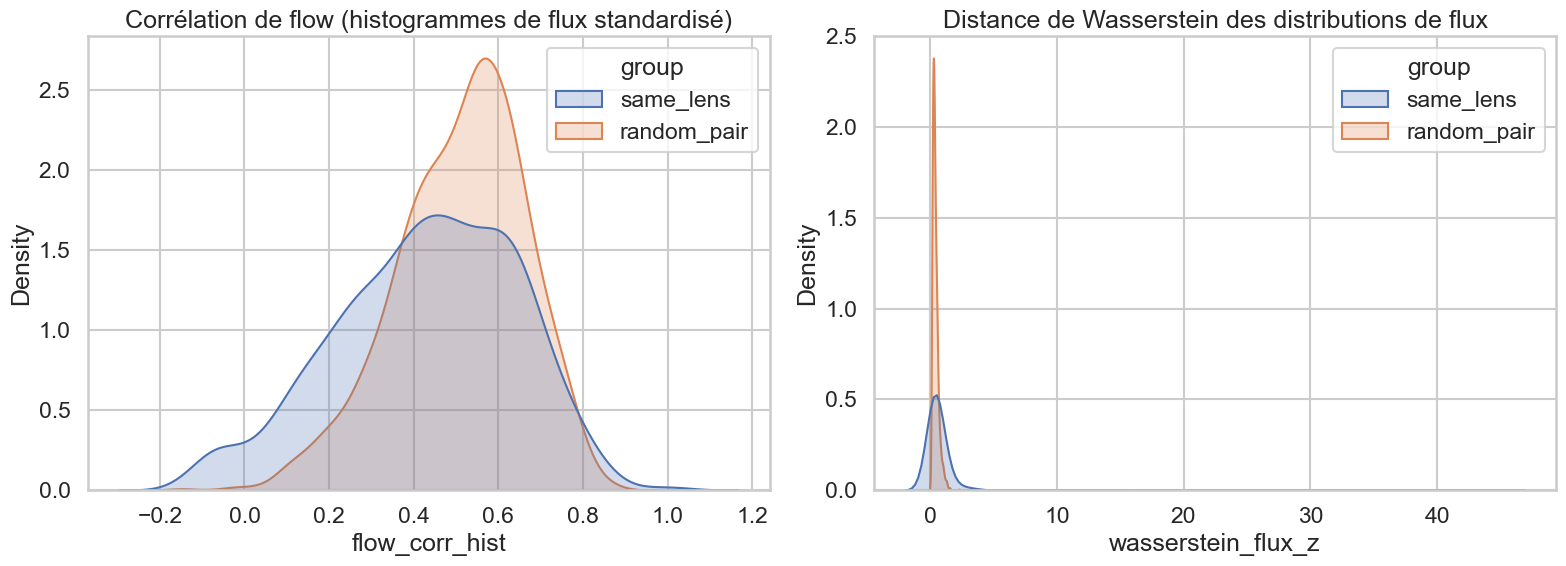

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(
    data=global_compare[global_compare["group"].isin(["same_lens", "random_pair"])],
    x="flow_corr_hist",
    hue="group",
    fill=True,
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title("Corrélation de flow (histogrammes de flux standardisé)")
axes[0].set_xlabel("flow_corr_hist")

sns.kdeplot(
    data=global_compare[global_compare["group"].isin(["same_lens", "random_pair"])],
    x="wasserstein_flux_z",
    hue="group",
    fill=True,
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("Distance de Wasserstein des distributions de flux")
axes[1].set_xlabel("wasserstein_flux_z")

plt.tight_layout()
save_figure("global_compare_same_lens_vs_random", fig=fig)
plt.show()

## 12. Top 10 composantes les plus observées

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\top10_lightcurves.png


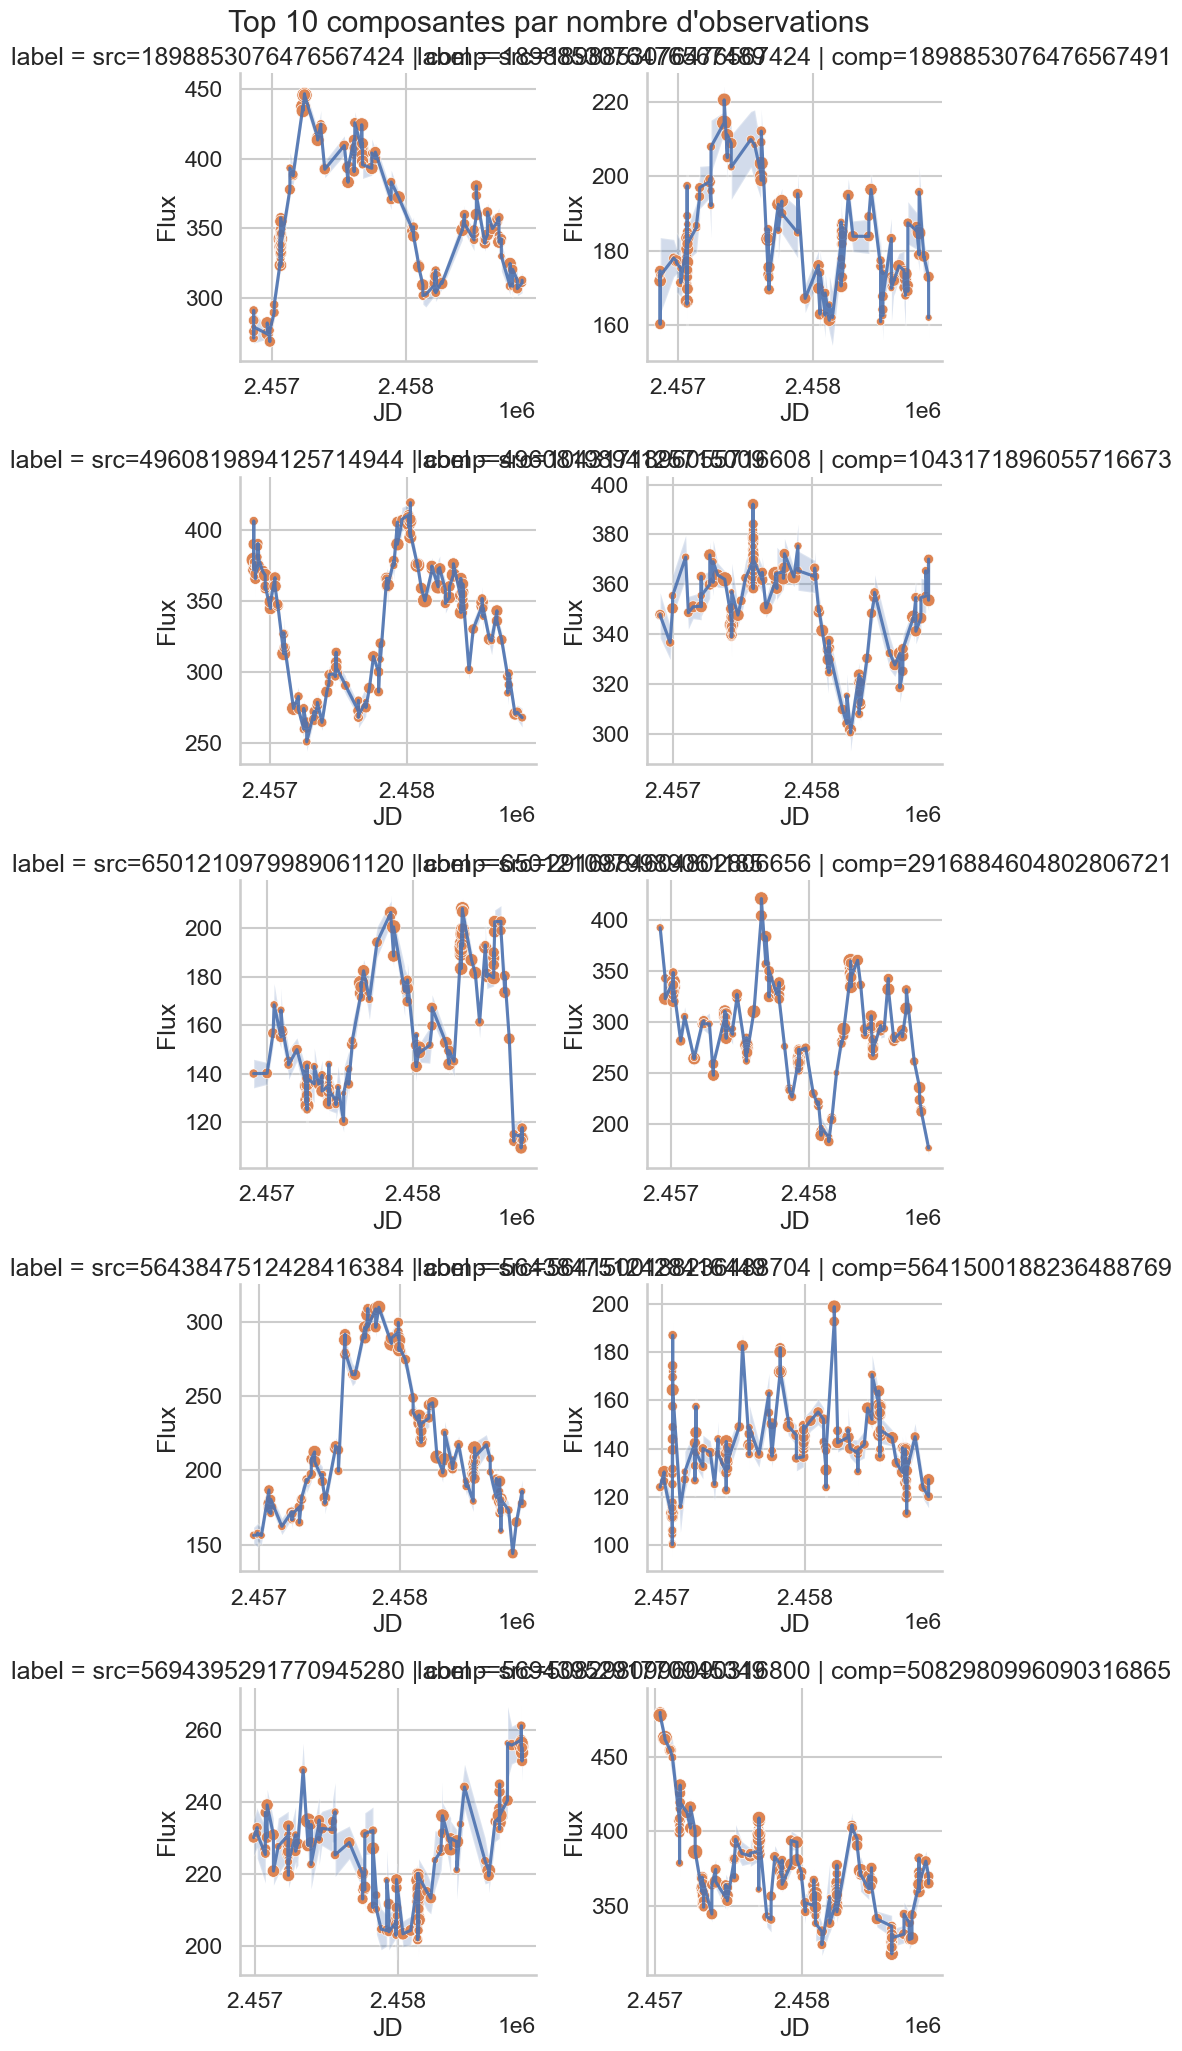

In [20]:
top10_comp = (
    work.groupby(["source_id", "lensComponentSourceId"])
        .size()
        .reset_index(name="n_obs")
        .sort_values("n_obs", ascending=False)
        .head(10)
)

top10_df = work.merge(top10_comp[["source_id", "lensComponentSourceId"]], on=["source_id", "lensComponentSourceId"], how="inner").copy()
top10_df["label"] = (
    "src=" + top10_df["source_id"].astype(str) + " | comp=" + top10_df["lensComponentSourceId"].astype(str)
)

g = sns.FacetGrid(
    top10_df.sort_values("epoch_obs_jd"),
    col="label",
    col_wrap=2,
    height=4.2,
    sharex=False,
    sharey=False
)

def plot_lc_with_band(data, color=None, **kwargs):
    ax = plt.gca()
    data = data.sort_values("epoch_obs_jd")
    ax.plot(data["epoch_obs_jd"], data["flux_obs"], alpha=0.9)
    ax.fill_between(
        data["epoch_obs_jd"].values,
        (data["flux_obs"] - data["flux_obs_error"]).values,
        (data["flux_obs"] + data["flux_obs_error"]).values,
        alpha=0.25
    )
    sns.scatterplot(
        data=data, x="epoch_obs_jd", y="flux_obs",
        size="snr", sizes=(20, 120), legend=False, ax=ax
    )
    ax.set_xlabel("JD")
    ax.set_ylabel("Flux")

g.map_dataframe(plot_lc_with_band)
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle("Top 10 composantes par nombre d'observations")
save_figure("top10_lightcurves", fig=g.fig)
plt.show()

## 13. Représentation probabiliste des 10 composantes

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\top10_flow_kde.png


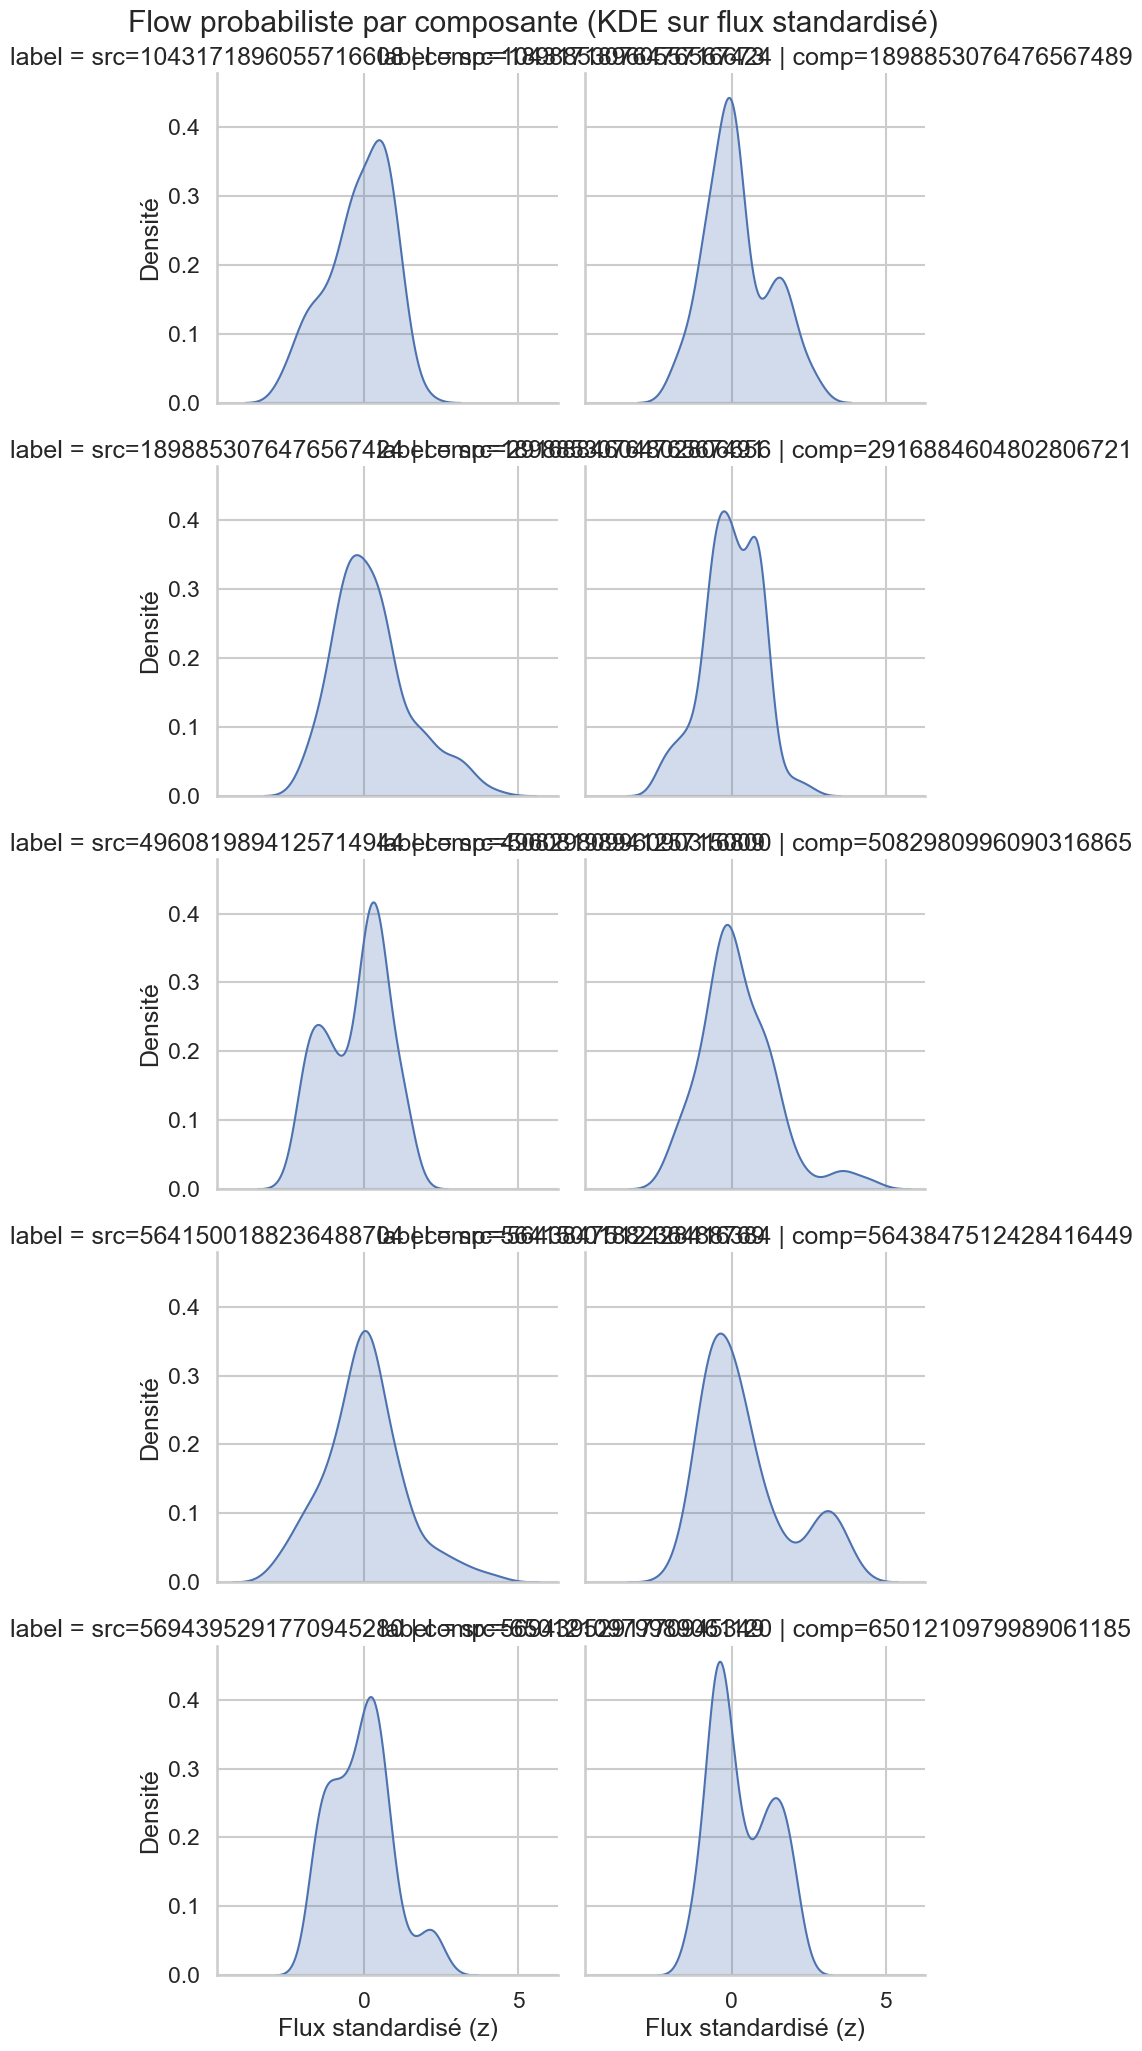

In [21]:
g = sns.FacetGrid(
    top10_df,
    col="label",
    col_wrap=2,
    height=4.2,
    sharex=True,
    sharey=True
)

g.map_dataframe(sns.kdeplot, x="flux_z", fill=True)
g.set_axis_labels("Flux standardisé (z)", "Densité")
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle("Flow probabiliste par composante (KDE sur flux standardisé)")
save_figure("top10_flow_kde", fig=g.fig)
plt.show()

## 14. Densité jointe temps--flux

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\joint_time_flux_density.png


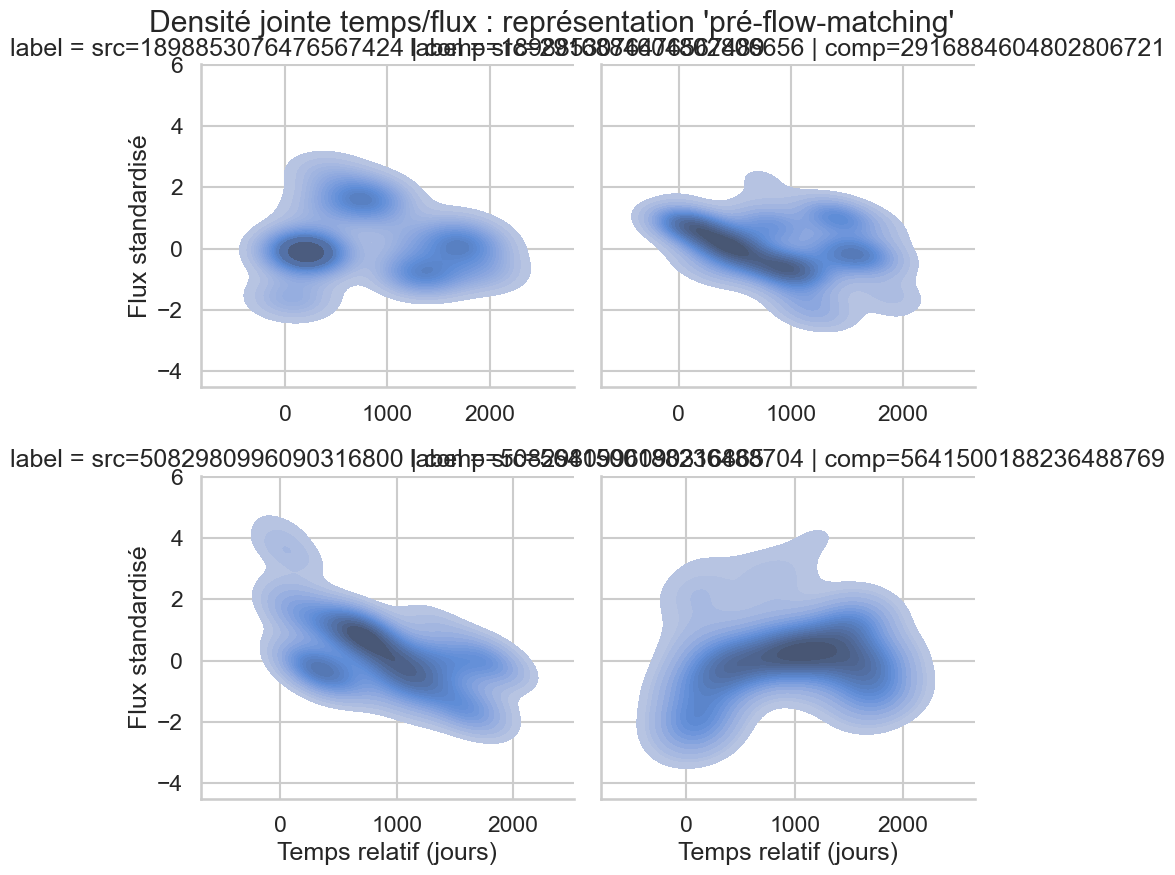

In [22]:
top4 = top10_comp.head(4).copy()
top4_df = work.merge(top4[["source_id", "lensComponentSourceId"]], on=["source_id", "lensComponentSourceId"])
top4_df["label"] = (
    "src=" + top4_df["source_id"].astype(str) + " | comp=" + top4_df["lensComponentSourceId"].astype(str)
)

g = sns.FacetGrid(
    top4_df,
    col="label",
    col_wrap=2,
    height=4.5,
    sharex=False,
    sharey=True
)

g.map_dataframe(
    sns.kdeplot,
    x="time_rel",
    y="flux_z",
    fill=True,
    thresh=0.05,
    levels=20
)
g.set_axis_labels("Temps relatif (jours)", "Flux standardisé")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Densité jointe temps/flux : représentation 'pré-flow-matching'")
save_figure("joint_time_flux_density", fig=g.fig)
plt.show()

## 15. Exemples de quads : courbes et flow global additif

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\quad_3511426761399556352_overview.png


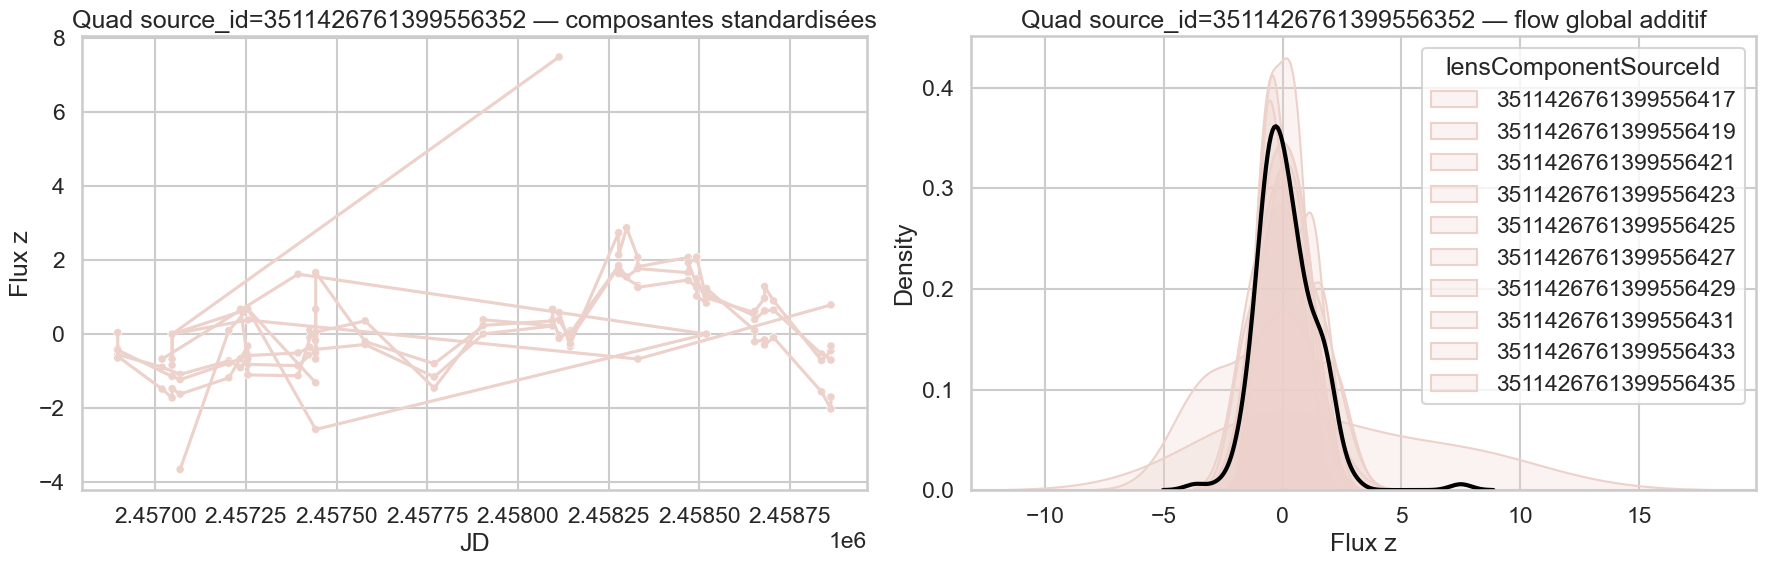

C:\Users\tpichard\AppData\Local\Temp\ipykernel_16824\2002733492.py:32: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\quad_1661333963305005184_overview.png


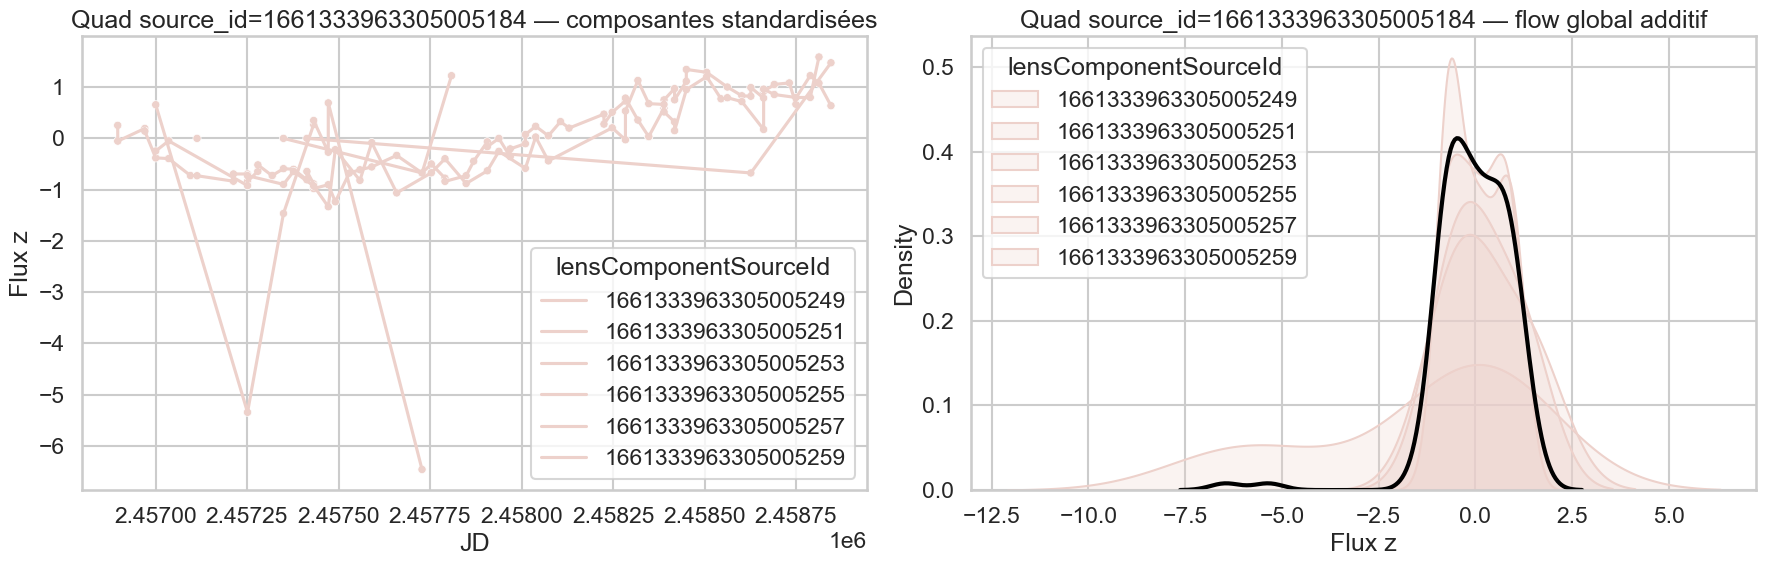

Figure exportée : C:\Users\tpichard\PyCS\figures_presentation\quad_83871575895472768_overview.png


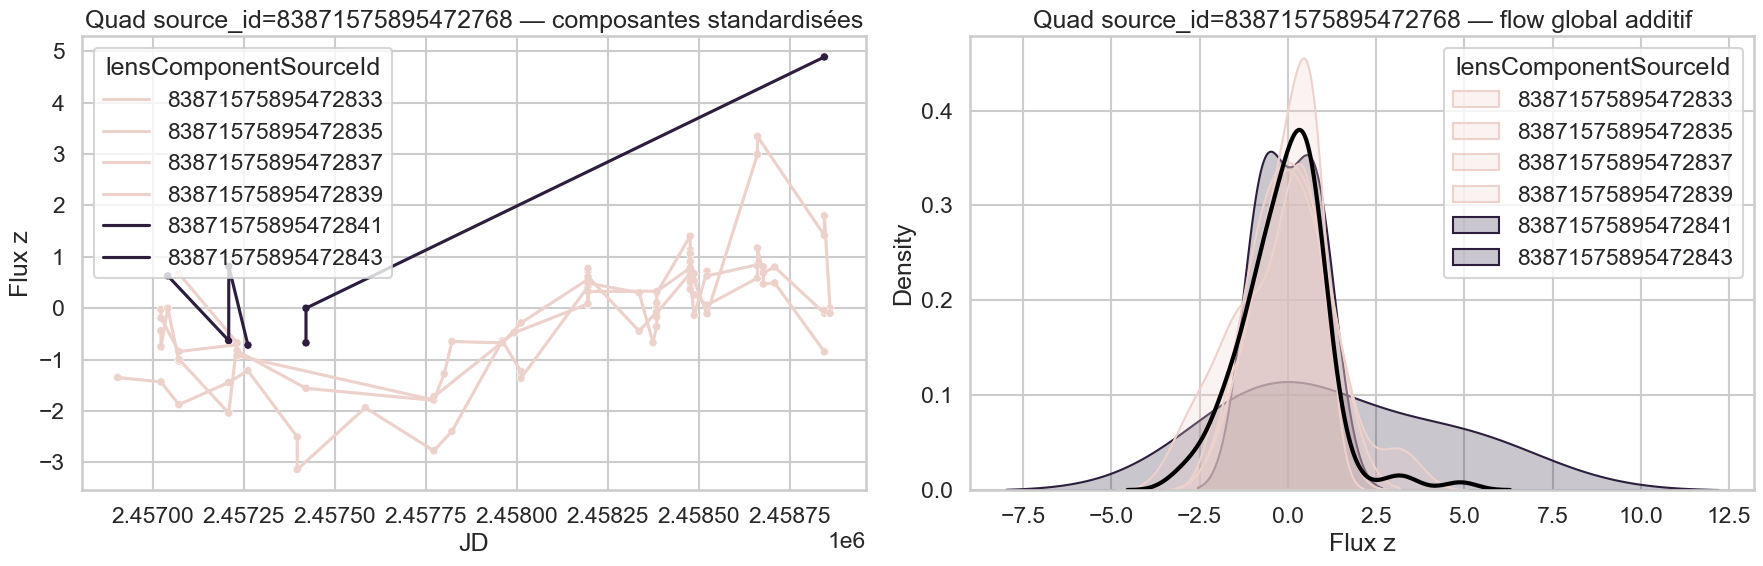

In [23]:
quad_sources = (
    work.groupby("source_id")["lensComponentSourceId"]
        .nunique()
        .reset_index(name="n_comp")
        .query("n_comp >= 4")
        .sort_values("n_comp", ascending=False)
)

quad_ids = quad_sources["source_id"].head(3).tolist()
quad_ids

for sid in quad_ids:
    sub = work[work["source_id"] == sid].copy()
    sub = sub.sort_values(["lensComponentSourceId", "epoch_obs_jd"])
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # gauche : light curves
    sns.lineplot(
        data=sub, x="epoch_obs_jd", y="flux_z",
        hue="lensComponentSourceId", estimator=None, ax=axes[0]
    )
    sns.scatterplot(
        data=sub, x="epoch_obs_jd", y="flux_z",
        hue="lensComponentSourceId", legend=False, s=35, ax=axes[0]
    )
    axes[0].set_title(f"Quad source_id={sid} — composantes standardisées")
    axes[0].set_xlabel("JD")
    axes[0].set_ylabel("Flux z")
    
    # droite : flow global additif
    sns.kdeplot(
        data=sub,
        x="flux_z",
        hue="lensComponentSourceId",
        fill=True,
        common_norm=False,
        alpha=0.25,
        ax=axes[1]
    )
    
    # densité totale additive
    sns.kdeplot(
        data=sub,
        x="flux_z",
        color="black",
        linewidth=3,
        ax=axes[1]
    )
    axes[1].set_title(f"Quad source_id={sid} — flow global additif")
    axes[1].set_xlabel("Flux z")
    
    plt.tight_layout()
    save_figure(f"quad_{sid}_overview", fig=fig)
    plt.show()

## 16. Résumé final par source

In [24]:
# Résumé par source : moyenne des similarités entre composantes
source_summary = (
    pairs_same_lens.groupby("source_id")
    .agg(
        n_pairs=("flow_corr_hist", "size"),
        flow_corr_mean=("flow_corr_hist", "mean"),
        flow_corr_std=("flow_corr_hist", "std"),
        weighted_corr_mean=("weighted_corr_interp", "mean"),
        wasserstein_mean=("wasserstein_flux_z", "mean"),
    )
    .reset_index()
)

source_summary = source_summary.merge(
    work.groupby("source_id")["lensComponentSourceId"].nunique().reset_index(name="n_comp"),
    on="source_id",
    how="left"
)

source_summary = source_summary.merge(
    work.groupby("source_id").size().reset_index(name="n_obs_total"),
    on="source_id",
    how="left"
)

source_summary.sort_values(["flow_corr_mean", "weighted_corr_mean"], ascending=False).head(20)

,source_id,n_pairs,flow_corr_mean,flow_corr_std,weighted_corr_mean,wasserstein_mean,n_comp,n_obs_total
317,6530870885967223936,1,0.872024,NaN,-0.768684,0.122135,2,172
112,2291297711623813632,1,0.856459,NaN,0.720190,0.133318,2,130
102,1783913498162557696,1,0.831769,NaN,0.604956,0.084871,2,136
257,4955044292688756224,1,0.828010,NaN,-0.842535,0.102136,2,223
140,2804295954148390272,1,0.826702,NaN,0.310677,0.178914,2,103
151,2964388321782713856,1,0.813005,NaN,0.744474,0.234174,2,208
116,2369490546185699328,1,0.806984,NaN,0.931890,0.144417,2,164
158,3138952727746236800,1,0.788898,NaN,0.880060,0.120090,2,85
271,5098921578230761472,1,0.783553,NaN,0.395869,0.358184,2,166
55,1043171896055716608,1,0.783264,NaN,-0.001590,0.268203,2,270


## 17. Guide de lecture

In [ ]:

# ------------------------------------------------------------------
# 7) Notes d'interprétation
# ------------------------------------------------------------------
# Colonnes utiles dans stats_comp :
# - nxs / nxs_err : variabilité intrinsèque normalisée et son incertitude approchée
# - weighted_kurtosis : forme de distribution du flux avec pondération par l'erreur
# - sf_slope : pente de structure function (info multi-échelle)
#
# Colonnes utiles dans pairs_same_lens / global_compare :
# - weighted_corr_interp : corrélation pondérée après interpolation temporelle
# - flow_corr_hist : similarité de "flow" via histogrammes de flux standardisé
# - wasserstein_flux_z : distance de transport entre distributions
#
# Idée générale :
# des composantes d'une même lentille devraient avoir des distributions / dynamiques plus proches
# que deux composantes prises au hasard dans le dataset.


## 18. Export récapitulatif pour la présentation

Cette section liste les figures exportées et propose, si besoin, une ré-exportation groupée.
Tu peux utiliser directement ces fichiers dans une future présentation Beamer ou PowerPoint.


In [ ]:

# ------------------------------------------------------------------
# Inventaire des figures exportées
# ------------------------------------------------------------------
exported_files = sorted(FIGURES_DIR.glob("*"))
print(f"{len(exported_files)} fichier(s) trouvé(s) dans {FIGURES_DIR.resolve()} :")
for p in exported_files:
    print(" -", p.name)
